# A Broad-Prior Stress Test For Joint SBI On $K_p$ And $K_d$

This notebook uses the same synthetic observation as the main joint demo, but now the prior is much broader.

The goal is to illustrate a practical point:

- with a broad prior and a small simulation budget, the posterior stays diffuse;
- with the same data but a larger sequential budget, the posterior tightens again.

We intentionally use a **broad but trainable** box prior.
An even larger box such as `[-10, 0]^2` for both gains made this small demo numerically unstable in practice.


In [1]:
import time
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings(
    "ignore",
    message="IProgress not found. Please update jupyter and ipywidgets.*",
)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from inference import posterior_summary, run_sequential_npe, sample_posterior_quiet
from simulator import JointDemoConfig, config_table, make_observation, true_parameter_table
from viz import plot_joint_posterior, plot_observation, plot_round_joint_posteriors

torch.set_num_threads(1)
pd.set_option("display.float_format", lambda value: f"{value:.4e}")


## 1. Fixed Observation, Much Broader Prior

The observation is kept informative:

- 14 hour window,
- 20 minute observations,
- nonzero initial offsets so both gains leave a visible signature.

Only the prior and the inference budget are stressed.


In [2]:
seed_obs = 11
theta_true = torch.tensor([-8.35, -3.9], dtype=torch.float32)

# Broad but still numerically manageable prior.
prior_bounds = ((-9.8, -6.8), (-5.8, -2.2))

config = JointDemoConfig(
    horizon_s=14.0 * 3600.0,
    dt_internal_s=30.0,
    dt_observation_s=20.0 * 60.0,
    process_noise_std=2.5e-6,
    controller_enabled=True,
    controller_gain_scale=1.0,
    initial_position_offset_km=(35.0, -20.0, 8.0),
    initial_velocity_offset_kms=(0.0, 0.0020, -0.0010),
)

num_posterior_samples = 800
round_posterior_sample_size = 300
restricted_prior_quantile = 5e-3
restricted_prior_support_samples = 4000

small_budget = {"label": "Small budget", "num_rounds": 3, "simulations_per_round": 64}
large_budget = {"label": "Larger budget", "num_rounds": 5, "simulations_per_round": 128}

x_o = make_observation(theta_true=theta_true, config=config, seed=seed_obs)

display(config_table(config))
display(true_parameter_table(theta_true))
print(f"Broad prior over log10(Kp): [{prior_bounds[0][0]:.1f}, {prior_bounds[0][1]:.1f}]")
print(f"Broad prior over log10(Kd): [{prior_bounds[1][0]:.1f}, {prior_bounds[1][1]:.1f}]")
print(
    f"Small budget: {small_budget['num_rounds']} rounds x "
    f"{small_budget['simulations_per_round']} sims/round"
)
print(
    f"Larger budget: {large_budget['num_rounds']} rounds x "
    f"{large_budget['simulations_per_round']} sims/round"
)


,quantity,value
0,Horizon [h],1.4000e+01
1,Internal integration step dt [s],3.0000e+01
2,Observation spacing DT [min],2.0000e+01
3,Number of internal steps,1680
4,Number of coarse observations,43
5,Observation dimension 6N,258
6,Controller enabled,True
7,Controller gain scale,1.0000e+00
8,Process noise std,2.5000e-06
9,Initial position offset [km],"(35.0, -20.0, 8.0)"


,parameter,value
0,log10(Kp),-8.3500e+00
1,Kp,4.4668e-09
2,log10(Kd),-3.9000e+00
3,Kd,1.2589e-04


Broad prior over log10(Kp): [-9.8, -6.8]
Broad prior over log10(Kd): [-5.8, -2.2]
Small budget: 3 rounds x 64 sims/round
Larger budget: 5 rounds x 128 sims/round


Observation dimension: 258 = 6 x 43


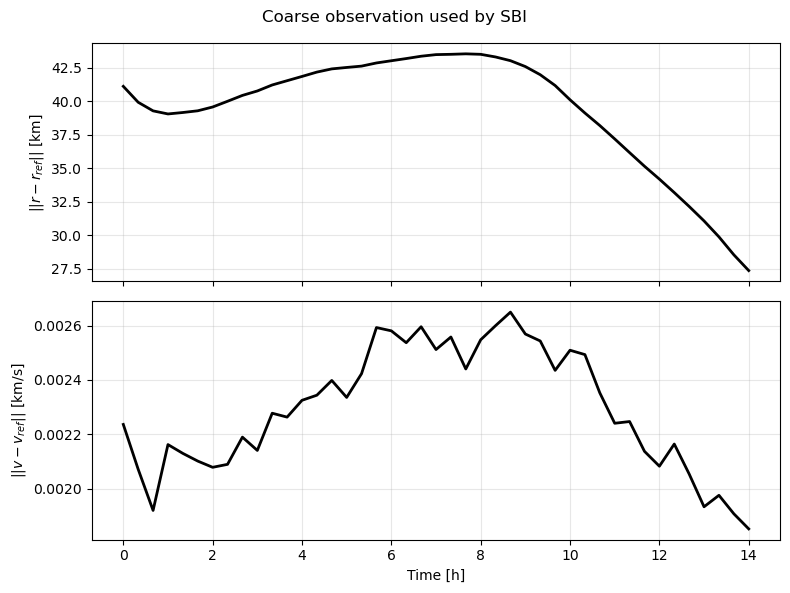

In [3]:
print(f"Observation dimension: {x_o.numel()} = 6 x {config.num_observations}")
plot_observation(x_o, config);


## 2. Helper To Run One Budget

We keep the observation and the prior fixed, and only change the sequential simulation budget.


In [4]:
def run_case(label: str, num_rounds: int, simulations_per_round: int, seed_inf: int = 7):
    start = time.perf_counter()
    result = run_sequential_npe(
        x_o=x_o,
        config=config,
        prior_bounds=prior_bounds,
        num_rounds=num_rounds,
        simulations_per_round=simulations_per_round,
        training_batch_size=64,
        round_posterior_sample_size=round_posterior_sample_size,
        restricted_prior_quantile=restricted_prior_quantile,
        restricted_prior_support_samples=restricted_prior_support_samples,
        seed=seed_inf,
    )
    samples = sample_posterior_quiet(
        result["posterior"],
        num_samples=num_posterior_samples,
        x=x_o,
    )
    elapsed_s = time.perf_counter() - start
    return {
        "label": label,
        "num_rounds": num_rounds,
        "simulations_per_round": simulations_per_round,
        "total_simulations": num_rounds * simulations_per_round,
        "elapsed_s": elapsed_s,
        "result": result,
        "samples": samples,
        "summary": posterior_summary(samples),
    }


def width90(samples: torch.Tensor, idx: int) -> float:
    values = samples[:, idx].detach().cpu().numpy()
    return float(np.quantile(values, 0.95) - np.quantile(values, 0.05))


def median_value(samples: torch.Tensor, idx: int) -> float:
    values = samples[:, idx].detach().cpu().numpy()
    return float(np.quantile(values, 0.5))


## 3. Small Budget Under The Broad Prior

This is intentionally under-powered for such a broad prior.


In [5]:
small = run_case(**small_budget)
print(small["result"]["method"])
display(pd.DataFrame(small["result"]["round_summaries"]))
display(small["summary"])


/home/roi.naveiro/anaconda3/envs/satellite-sbi/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Sequential NPE with zuko_maf, a learned trajectory embedding, and restricted-prior proposals


,round,proposal,num_simulations,x_dimension,log10_kp_q05,log10_kp_median,log10_kp_q95,log10_kd_q05,log10_kd_median,log10_kd_q95,posterior_corr
0,1,prior,64,258,-9.6123e+00,-8.2291e+00,-7.0942e+00,-5.4616e+00,-4.2733e+00,-3.0816e+00,-6.5007e-02
1,2,restricted prior,64,258,-9.4979e+00,-8.2877e+00,-7.0845e+00,-5.5649e+00,-4.1641e+00,-2.7535e+00,7.2655e-02
2,3,restricted prior,64,258,-9.4471e+00,-8.0839e+00,-7.0143e+00,-4.2595e+00,-3.6947e+00,-3.0975e+00,-9.5015e-02


,parameter,q05,median,q95
0,log10(Kp),-9.3952e+00,-8.2068e+00,-7.0626e+00
1,Kp,4.0255e-10,6.2118e-09,8.6577e-08
2,log10(Kd),-4.2770e+00,-3.6764e+00,-3.0454e+00
3,Kd,5.2842e-05,2.1068e-04,9.0071e-04


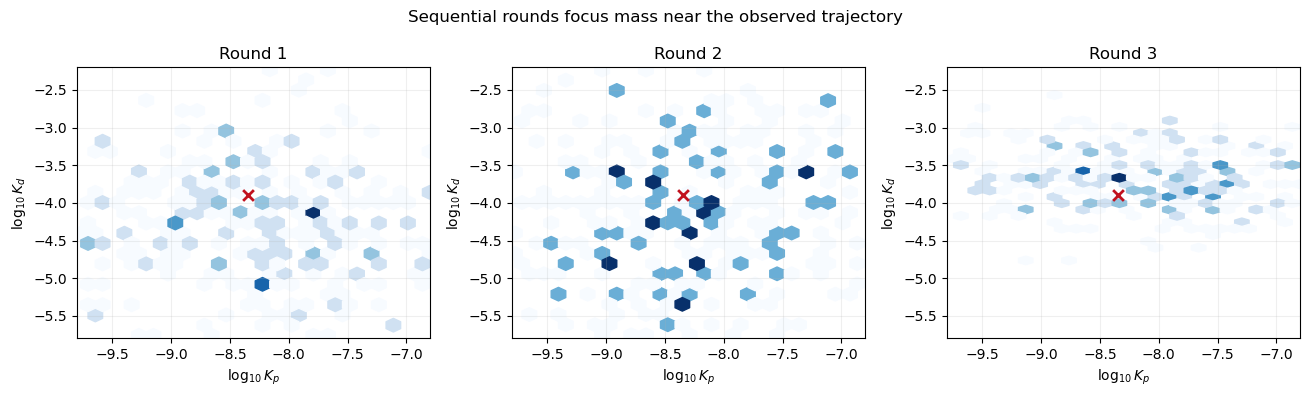

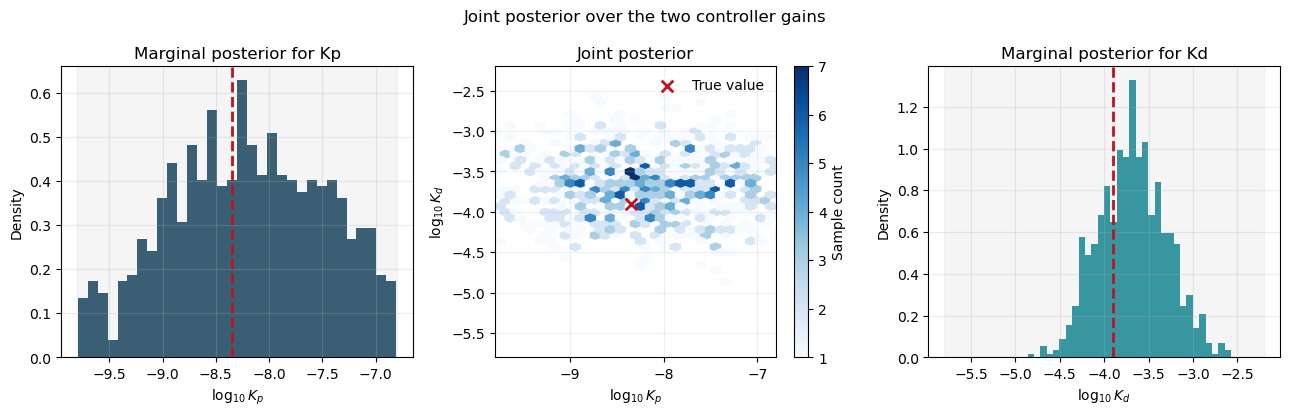

In [6]:
plot_round_joint_posteriors(
    small["result"]["round_posterior_samples"],
    prior_bounds=prior_bounds,
    theta_true=theta_true,
);
plot_joint_posterior(
    small["samples"],
    prior_bounds=prior_bounds,
    theta_true=theta_true,
);


## 4. Larger Sequential Budget, Same Broad Prior

Now we keep the exact same observation and prior, but allocate more sequential simulations.


In [7]:
large = run_case(**large_budget)
print(large["result"]["method"])
display(pd.DataFrame(large["result"]["round_summaries"]))
display(large["summary"])


Sequential NPE with zuko_maf, a learned trajectory embedding, and restricted-prior proposals


,round,proposal,num_simulations,x_dimension,log10_kp_q05,log10_kp_median,log10_kp_q95,log10_kd_q05,log10_kd_median,log10_kd_q95,posterior_corr
0,1,prior,128,258,-9.3450e+00,-8.2025e+00,-7.1041e+00,-5.1385e+00,-4.0442e+00,-3.0433e+00,6.1994e-02
1,2,restricted prior,128,258,-9.4496e+00,-8.5749e+00,-7.5601e+00,-4.5335e+00,-3.9199e+00,-3.3462e+00,1.3419e-02
2,3,restricted prior,128,258,-8.9734e+00,-8.4446e+00,-8.0453e+00,-4.2576e+00,-3.9542e+00,-3.6391e+00,2.0530e-02
3,4,restricted prior,128,258,-8.7600e+00,-8.4661e+00,-8.1801e+00,-3.9915e+00,-3.9211e+00,-3.8429e+00,1.0331e-01
4,5,restricted prior,128,258,-8.6039e+00,-8.3929e+00,-8.1759e+00,-3.9628e+00,-3.9042e+00,-3.8453e+00,2.3566e-01


,parameter,q05,median,q95
0,log10(Kp),-8.6265e+00,-8.4035e+00,-8.1904e+00
1,Kp,2.3632e-09,3.9489e-09,6.4512e-09
2,log10(Kd),-3.9697e+00,-3.9079e+00,-3.8487e+00
3,Kd,1.0722e-04,1.2362e-04,1.4168e-04


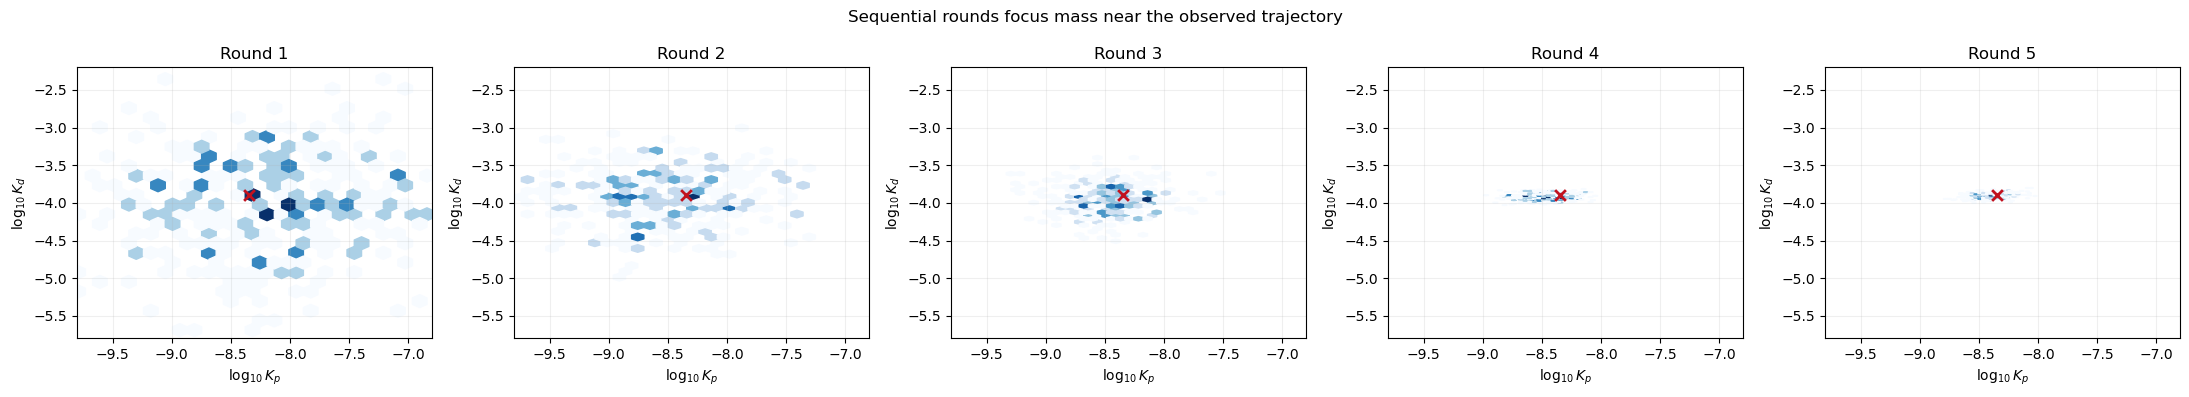

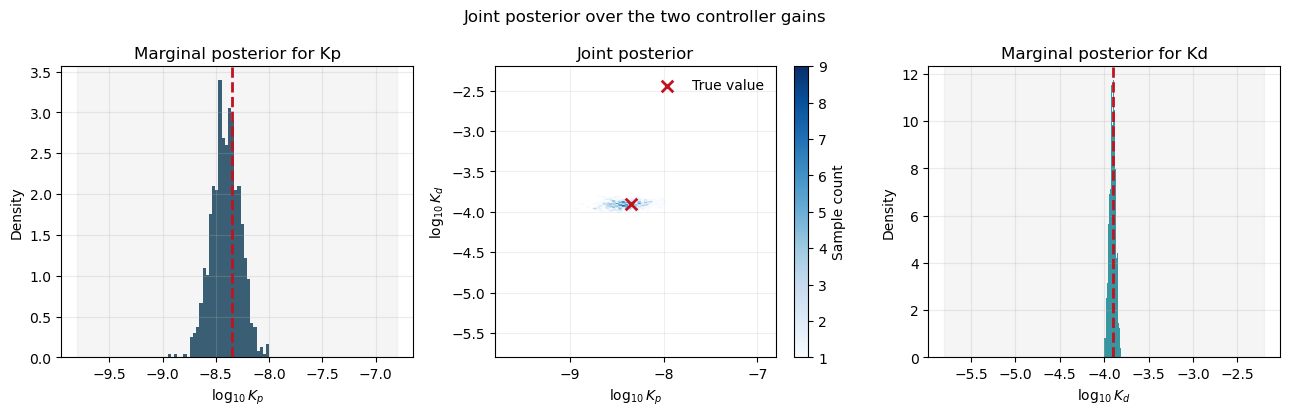

In [8]:
plot_round_joint_posteriors(
    large["result"]["round_posterior_samples"],
    prior_bounds=prior_bounds,
    theta_true=theta_true,
);
plot_joint_posterior(
    large["samples"],
    prior_bounds=prior_bounds,
    theta_true=theta_true,
);
